In [4]:
import math
import matplotlib.pyplot as mpl
import numpy as np

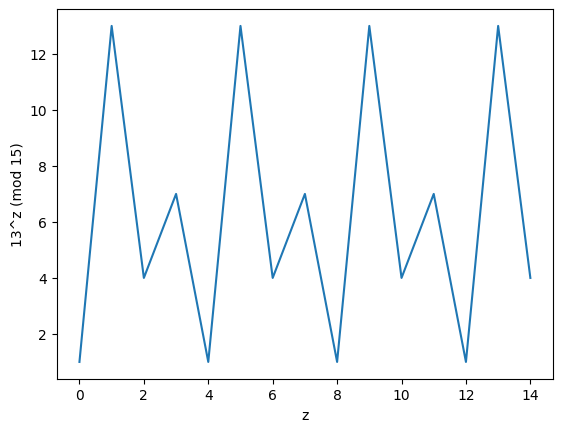

4
x: 4.0
5 3


In [5]:
N = 15
a = 13

#N = 21
#a = 2
math.gcd(a, N)
z = list(range(N))
y = [a**z0 % N for z0 in z]

mpl.plot(z,y)
mpl.xlabel('z')
mpl.ylabel(f'{a}^z (mod {N})')
mpl.show()

r = z[y[1:].index(1)+1]
print(r)

if r % 2 == 0:
    x = (a**(r/2.)) % N
    print(f'x: {x}')
    if((x+1) % N) != 0:
        print(math.gcd((int(x)+1),N), math.gcd((int(x)-1),N))
    else:
        print('x+1 is 0 (mod N)')
else:
    print('r is odd')


In [1]:
#%pip install qiskit-algorithms

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import QFT # Inverse QFT için hazır kapı
import matplotlib.pyplot as plt

C:\Users\umran\AppData\Local\Temp\ipykernel_25788\4153955192.py:37: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.append(QFT(n_count, inverse=True).to_gate(), range(n_count))


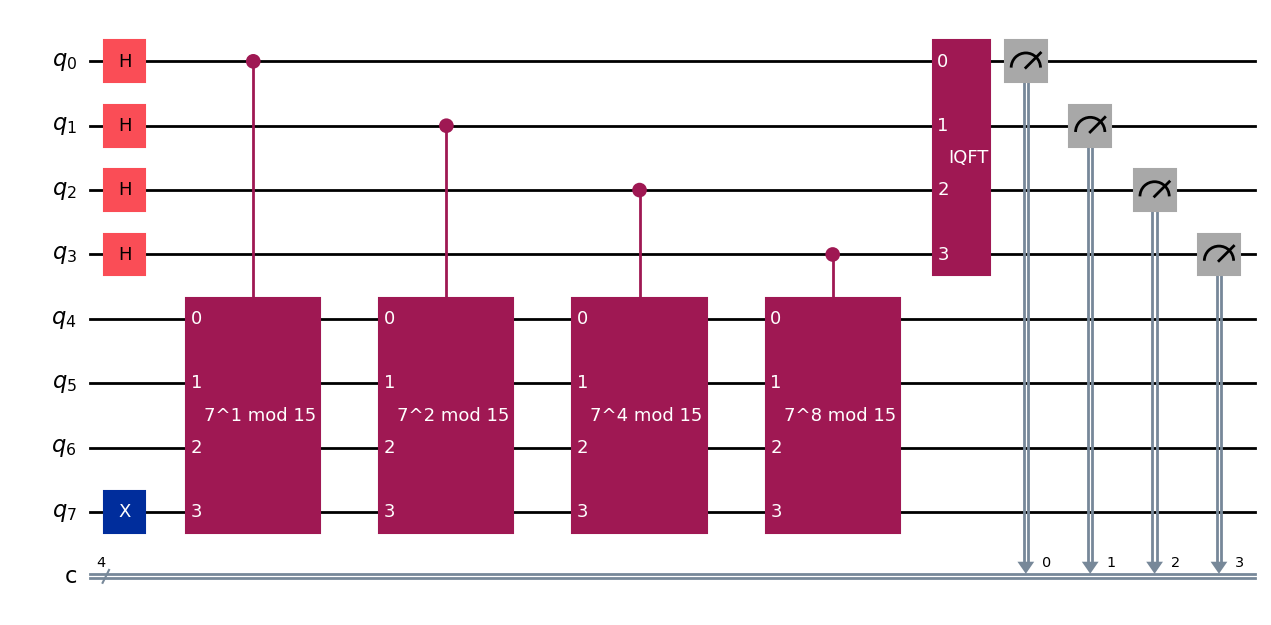


Ölçüm Sonuçları (Periyot İpuçları): {'0000': 239, '1000': 253, '0100': 280, '1100': 252}


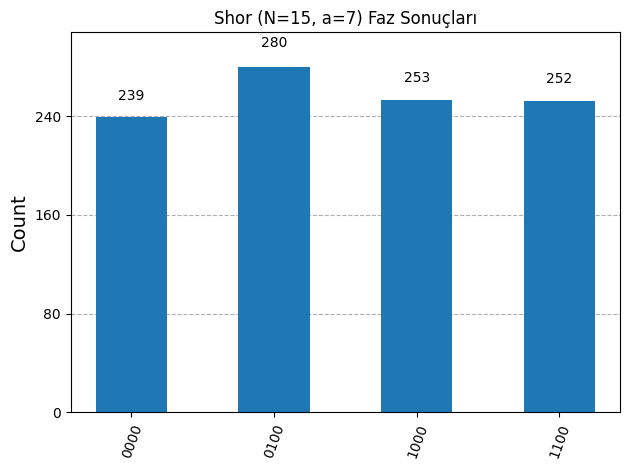

In [7]:
# YARDIMCI FONKSİYON: c_amod15 
# Bu fonksiyon 7^x mod 15 işlemini yapan kuantum kapılarını oluşturur.
# Bu kısım N=15 ve a=7'ye özel olarak tasarlanmıştır.
def c_amod15(power):
    """N=15 ve a=7 için kontrollü modüler üs alma kapısı"""
    U = QuantumCircuit(4)        
    for _ in range(power):
        # a = 7 için modüler çarpma işlemi (SWAP kapılarıyla yapılır)
        # 7 * x mod 15 işlemi bitleri karıştırır:
        U.swap(2, 3)
        U.swap(1, 2)
        U.swap(0, 1)
        for q in range(4):
            U.x(q)
    U = U.to_gate()
    U.name = "%i^%i mod 15" % (7, power)
    return U.control() # Kontrollü kapı olarak döndür

# 4 Sayma Kübiti (Hassasiyet için) + 4 Hedef Kübit (Modüler aritmetik için)
n_count = 4 
circuit = QuantumCircuit(n_count + 4, n_count)

# Sayma kübitlerine Hadamard (Süperpozisyon)
for q in range(n_count):
    circuit.h(q)

# Hedef kübitleri |1> durumuna hazırla (Son kübite X)
circuit.x(n_count + 3) # Çünkü Qiskit tersten dizer, en alt bit aslında 1 olmalı

# Modüler Üs Alma (Modular Exponentiation)
# Shor algoritmasının en zor kısmı burasıdır.
for q in range(n_count):
    circuit.append(c_amod15(2**q), [q] + [i+n_count for i in range(4)])

# Inverse QFT (Ters Kuantum Fourier Dönüşümü)
# QFT kütüphanesini kullanıyoruz ama 'inverse=True' diyerek tersini alıyoruz.
circuit.append(QFT(n_count, inverse=True).to_gate(), range(n_count))

circuit.measure(range(n_count), range(n_count))

display(circuit.draw(output='mpl', fold=-1))

simulator = AerSimulator()
t_circ = transpile(circuit, simulator)
result = simulator.run(t_circ, shots=1024).result()
counts = result.get_counts()

print("\nÖlçüm Sonuçları (Periyot İpuçları):", counts)
display(plot_histogram(counts, title="Shor (N=15, a=7) Faz Sonuçları"))

In [8]:
for y in range(15):
    result = np.exp(-1j*3*np.pi/8*y) + np.exp(-1j*7*np.pi/8*y) + np.exp(-1j*11*np.pi/8*y) + np.exp(-1j*15*np.pi/8*y)
    if abs(result) < 1e-10: 
        result = 0
    print(y, result)

0 (4+0j)
1 0
2 0
3 0
4 (-5.757077917265737e-15+4j)
5 0
6 0
7 0
8 (-4-1.1514155834531474e-14j)
9 0
10 0
11 0
12 (2.2600304269997962e-14-4j)
13 0
14 0
